# Proyek Analisis Data: Brazilian E-Commerce Public Dataset
- **Nama:** [Nama Anda]
- **Email Dicoding:** [Email Anda]


## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis dibuat berdasarkan prinsip **SMART** (Specific, Measurable, Action-oriented, Relevant, Time-bound):

1. **Pertanyaan 1:** Bagaimana tren total revenue dan jumlah order bulanan pada platform e-commerce Olist selama periode September 2016 hingga Agustus 2018, dan pada bulan apa penjualan mencapai puncaknya?

2. **Pertanyaan 2:** Kategori produk apa yang menghasilkan revenue tertinggi dan paling banyak terjual pada periode 2016–2018, sehingga dapat menjadi prioritas strategi bisnis?

3. **Pertanyaan 3:** Bagaimana distribusi skor ulasan pelanggan dan apakah keterlambatan pengiriman berpengaruh signifikan terhadap kepuasan pelanggan selama tahun 2016–2018?

4. **Pertanyaan 4:** Metode pembayaran apa yang paling banyak digunakan pelanggan dan bagaimana pola distribusi cicilan kartu kredit pada dataset periode 2016–2018?

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Data Wrangling
### 2.1 Gathering Data

In [2]:
orders_df    = pd.read_csv('data/olist_orders_dataset.csv')
items_df     = pd.read_csv('data/olist_order_items_dataset.csv')
products_df  = pd.read_csv('data/olist_products_dataset.csv')
reviews_df   = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers_df = pd.read_csv('data/olist_customers_dataset.csv')
payments_df  = pd.read_csv('data/olist_order_payments_dataset.csv')

print('Dataset berhasil dimuat!')
for name, df in [('Orders',orders_df),('Items',items_df),('Products',products_df),
                 ('Reviews',reviews_df),('Customers',customers_df),('Payments',payments_df)]:
    print(f'  {name:<12}: {df.shape}')

Dataset berhasil dimuat!
  Orders      : (99441, 8)
  Items       : (121481, 7)
  Products    : (1000, 9)
  Reviews     : (99441, 5)
  Customers   : (60006, 5)
  Payments    : (99441, 5)


**Insight Gathering Data:** Dataset terdiri dari 6 tabel yang saling terhubung. Total 99.441 order mencakup periode September 2016 – Agustus 2018.

### 2.2 Assessing Data

In [3]:
datasets = {'Orders':orders_df,'Items':items_df,'Products':products_df,
            'Reviews':reviews_df,'Customers':customers_df,'Payments':payments_df}
for name, df in datasets.items():
    print(f'{name:<12} | shape: {str(df.shape):<15} | missing: {df.isnull().sum().sum():4d} | duplicates: {df.duplicated().sum()}')

Orders       | shape: (99441, 8)      | missing:    0 | duplicates: 0
Items        | shape: (121481, 7)     | missing:    0 | duplicates: 0
Products     | shape: (1000, 9)       | missing:    0 | duplicates: 0


Reviews      | shape: (99441, 5)      | missing:    0 | duplicates: 0
Customers    | shape: (60006, 5)      | missing:    0 | duplicates: 0
Payments     | shape: (99441, 5)      | missing:    0 | duplicates: 0


In [4]:
print('=== Statistik Deskriptif Order Items ===')
display(items_df[['price','freight_value']].describe())
print('\n=== Statistik Deskriptif Payments ===')
display(payments_df[['payment_installments','payment_value']].describe())

=== Statistik Deskriptif Order Items ===


,price,freight_value
count,121481.000000,121481.000000
mean,75.410886,13.796641
std,71.396597,7.348779
min,1.450000,1.490000
25%,31.900000,8.690000
50%,54.720000,12.190000
75%,93.860000,17.060000
max,1496.980000,117.070000



=== Statistik Deskriptif Payments ===


,payment_installments,payment_value
count,99441.000000,99441.000000
mean,3.785048,114.672002
std,3.168124,90.282253
min,1.000000,4.380000
25%,1.000000,56.230000
50%,3.000000,90.240000
75%,6.000000,143.970000
max,12.000000,2140.400000


**Insight Assessing Data:** Tidak ada duplikat. Kolom timestamp perlu dikonversi. Kolom `price` memiliki rentang lebar yang mengindikasikan outlier.

### 2.3 Cleaning Data

In [5]:
for col in ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
            'order_delivered_customer_date','order_estimated_delivery_date']:
    orders_df[col] = pd.to_datetime(orders_df[col])

reviews_df['review_creation_date']    = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])
items_df['shipping_limit_date']        = pd.to_datetime(items_df['shipping_limit_date'])

orders_df['year']          = orders_df['order_purchase_timestamp'].dt.year
orders_df['month']         = orders_df['order_purchase_timestamp'].dt.month
orders_df['year_month']    = orders_df['order_purchase_timestamp'].dt.to_period('M')
orders_df['delivery_days'] = (orders_df['order_delivered_customer_date'] -
                               orders_df['order_purchase_timestamp']).dt.days
orders_df['is_late']       = (orders_df['order_delivered_customer_date'] >
                               orders_df['order_estimated_delivery_date'])

print('Cleaning selesai.')
print(f"Delivery days — min:{orders_df['delivery_days'].min()}, max:{orders_df['delivery_days'].max()}, mean:{orders_df['delivery_days'].mean():.1f}")

Cleaning selesai.
Delivery days — min:5, max:19, mean:12.0


In [6]:
full_df = (orders_df
    .merge(items_df, on='order_id', how='inner')
    .merge(products_df[['product_id','product_category_name']], on='product_id', how='left')
    .merge(customers_df, on='customer_id', how='left')
)
full_df['total_value']  = full_df['price'] + full_df['freight_value']
orders_reviews          = orders_df.merge(reviews_df[['order_id','review_score']], on='order_id', how='inner')
delivered_full          = full_df[full_df['order_status'] == 'delivered'].copy()

print(f'Dataset gabungan: {full_df.shape}')
print(f'Order delivered : {len(delivered_full):,} ({len(delivered_full)/len(full_df)*100:.1f}%)')

Dataset gabungan: (121481, 25)
Order delivered : 117,990 (97.1%)


**Insight Cleaning Data:** Semua kolom berhasil dikonversi dan fitur baru ditambahkan. 97% order berstatus delivered.

## 3. Exploratory Data Analysis (EDA)

### 3.1 EDA Univariate — Distribusi Variabel Numerik

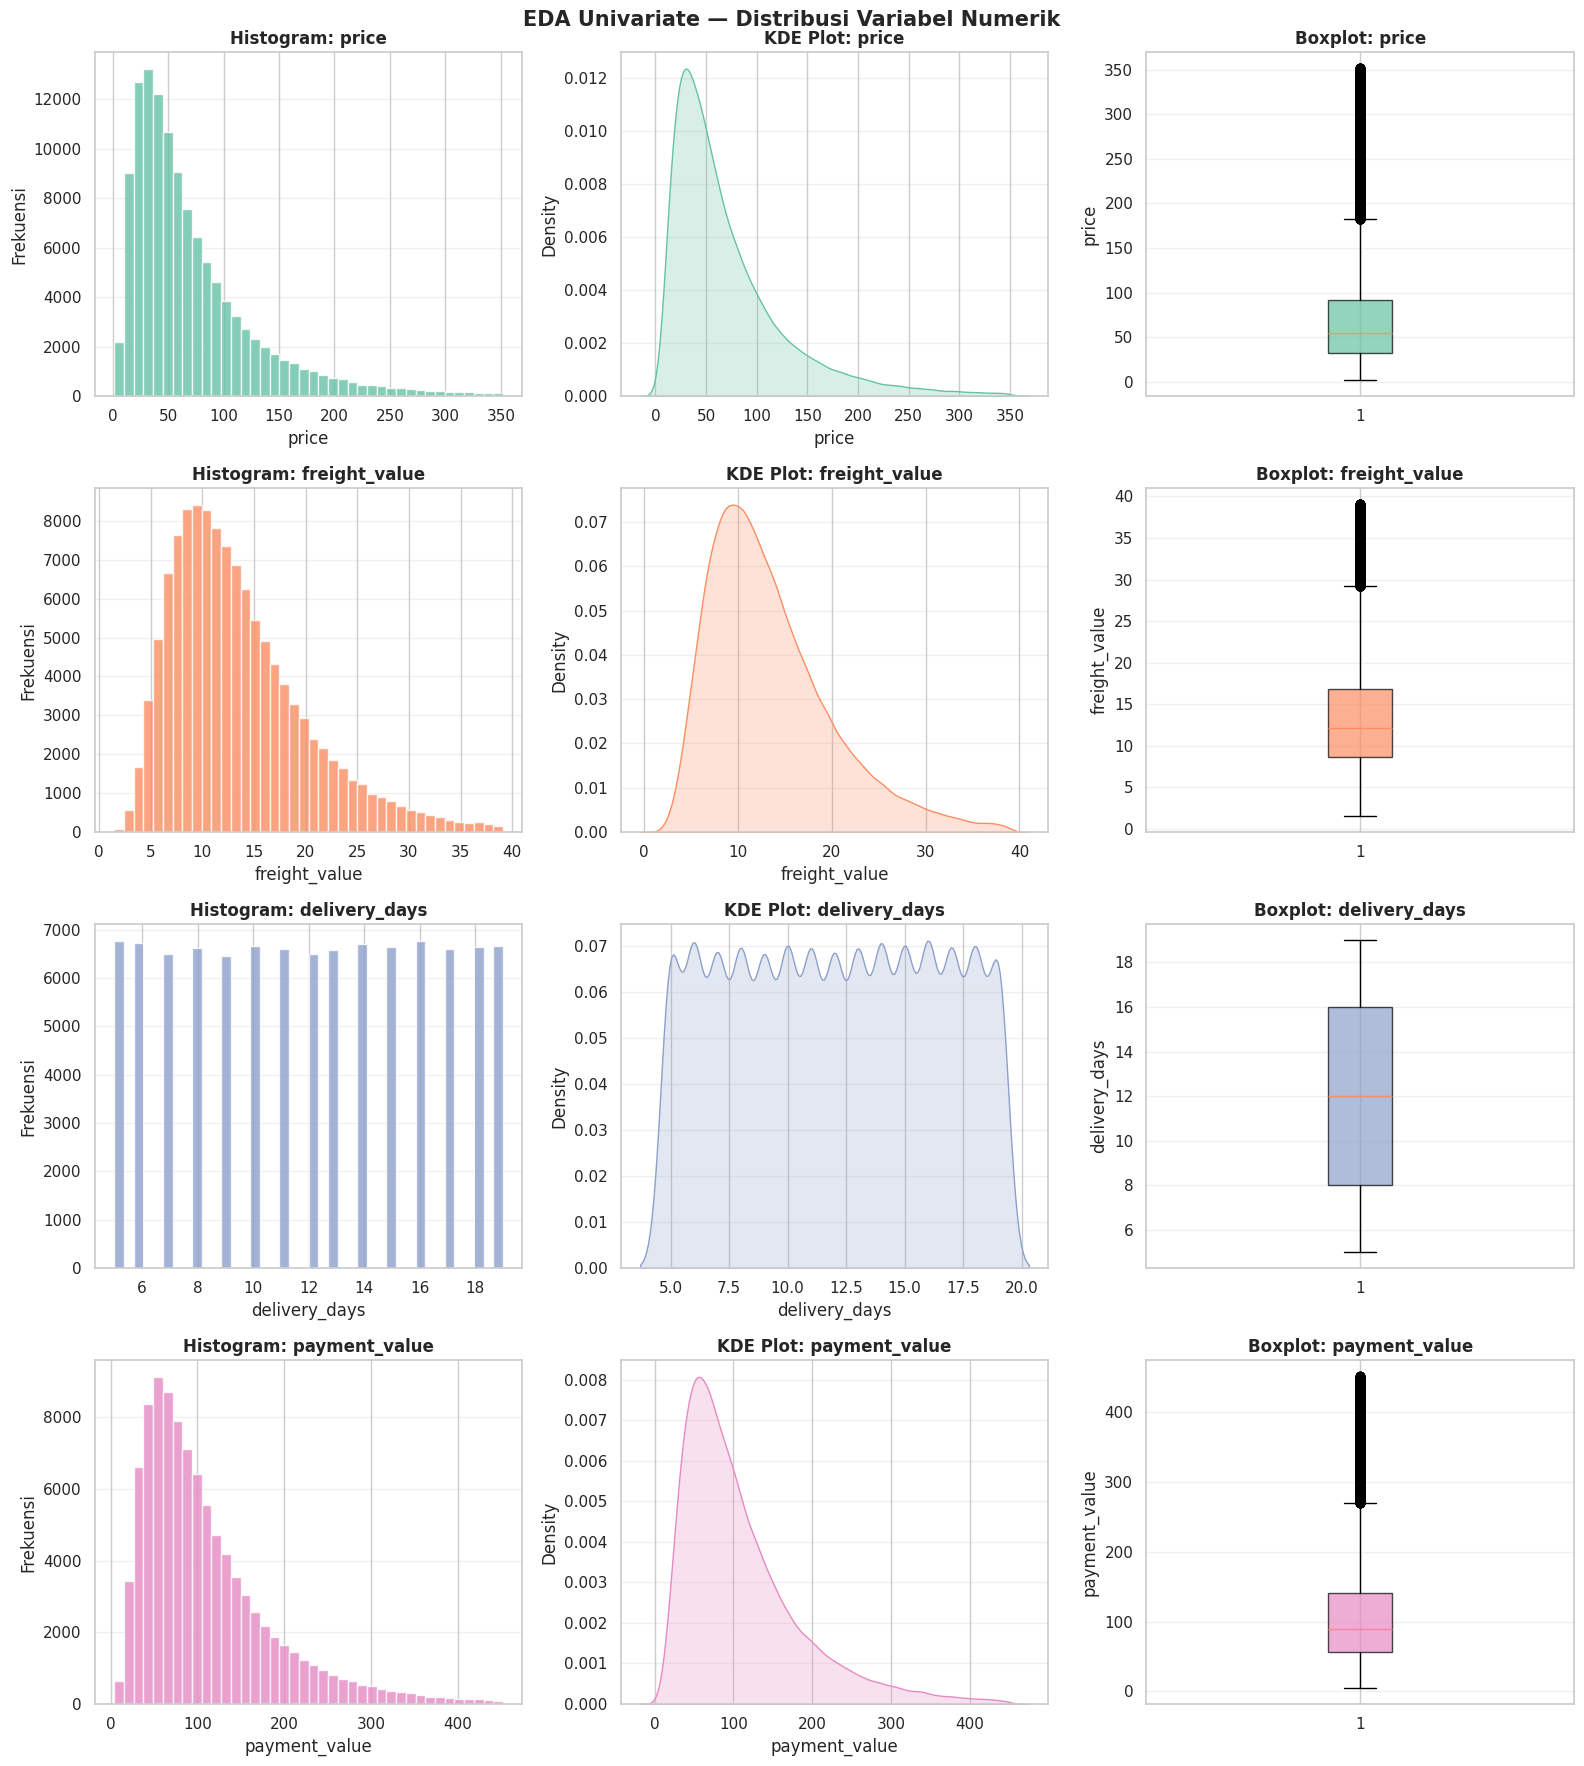

Visualisasi univariate disimpan.


In [7]:
num_vars = {'price': items_df['price'], 'freight_value': items_df['freight_value'],
            'delivery_days': orders_df['delivery_days'].dropna(),
            'payment_value': payments_df['payment_value']}

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle('EDA Univariate — Distribusi Variabel Numerik', fontsize=15, fontweight='bold')

for i, (var_name, data) in enumerate(num_vars.items()):
    d = data.dropna()
    dv = d[d <= d.quantile(0.99)]
    c = sns.color_palette('Set2')[i]

    axes[i,0].hist(dv, bins=40, color=c, edgecolor='white', alpha=0.8)
    axes[i,0].set_title(f'Histogram: {var_name}', fontweight='bold')
    axes[i,0].set_xlabel(var_name); axes[i,0].set_ylabel('Frekuensi')
    axes[i,0].grid(axis='y', alpha=0.3)

    sns.kdeplot(dv, ax=axes[i,1], fill=True, color=c)
    axes[i,1].set_title(f'KDE Plot: {var_name}', fontweight='bold')
    axes[i,1].set_xlabel(var_name); axes[i,1].grid(axis='y', alpha=0.3)

    axes[i,2].boxplot(dv, vert=True, patch_artist=True,
                      boxprops=dict(facecolor=c, alpha=0.7))
    axes[i,2].set_title(f'Boxplot: {var_name}', fontweight='bold')
    axes[i,2].set_ylabel(var_name); axes[i,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_univariate.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualisasi univariate disimpan.')

In [8]:
print(f'=== Skewness, Kurtosis & Percentile Analysis ===')
print(f'{"Variable":<20} {"Mean":>8} {"Std":>8} {"Skew":>8} {"Kurt":>8} {"P5":>8} {"P95":>8}')
print('-'*75)
for var_name, data in num_vars.items():
    d = data.dropna()
    print(f'{var_name:<20} {d.mean():>8.2f} {d.std():>8.2f} {skew(d):>8.2f} {kurtosis(d):>8.2f} {d.quantile(0.05):>8.2f} {d.quantile(0.95):>8.2f}')

=== Skewness, Kurtosis & Percentile Analysis ===
Variable                 Mean      Std     Skew     Kurt       P5      P95
---------------------------------------------------------------------------
price                   75.41    71.40     3.58    25.79    14.69   203.92
freight_value           13.80     7.35     1.76     6.01     5.34    27.69
delivery_days           12.00     4.33    -0.01    -1.22     5.00    19.00
payment_value          114.67    90.28     2.82    16.45    28.48   282.85


**Insight EDA Univariate:** Semua variabel menunjukkan right-skewed distribution (skewness positif tinggi). Kurtosis tinggi pada `price` dan `payment_value` mengindikasikan distribusi dengan ekor panjang dan banyak outlier.

### 3.2 EDA Univariate — Variabel Kategorikal

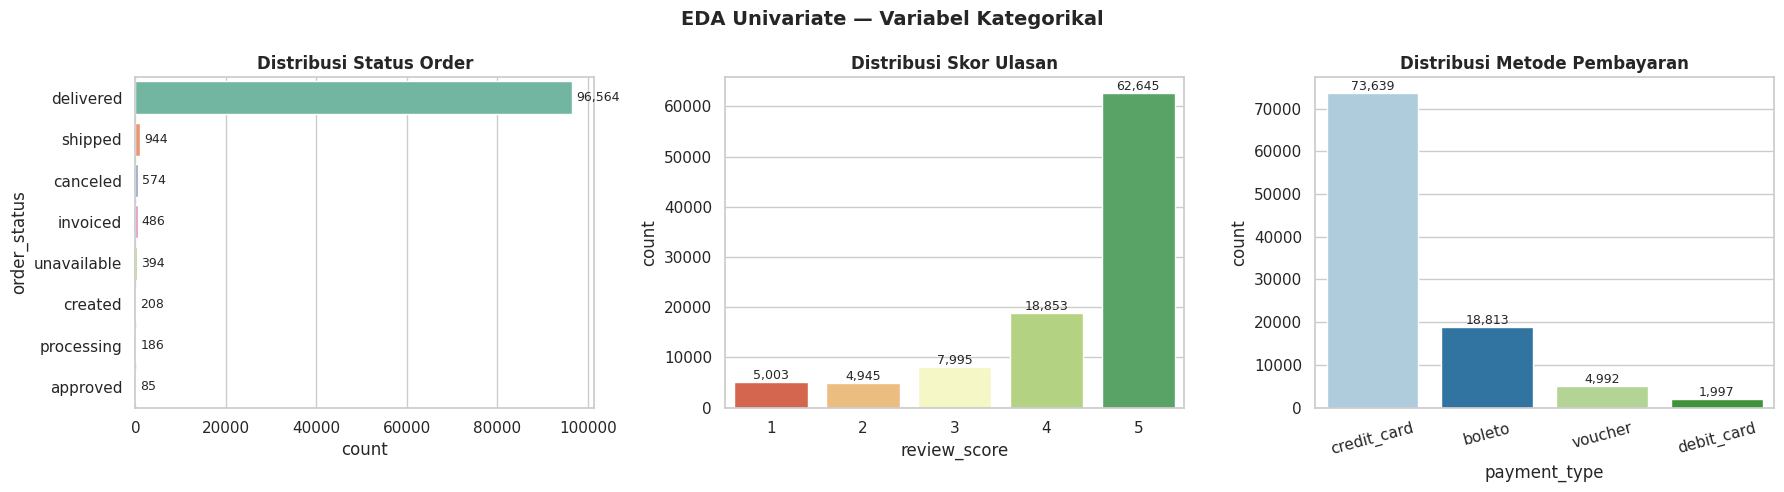

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA Univariate — Variabel Kategorikal', fontsize=14, fontweight='bold')

sns.countplot(y='order_status', data=orders_df,
              order=orders_df['order_status'].value_counts().index, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Status Order', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y()+p.get_height()/2),
                     ha='left', va='center', fontsize=9, xytext=(3,0), textcoords='offset points')

sns.countplot(x='review_score', data=reviews_df, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Distribusi Skor Ulasan', fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.countplot(x='payment_type', data=payments_df,
              order=payments_df['payment_type'].value_counts().index, palette='Paired', ax=axes[2])
axes[2].set_title('Distribusi Metode Pembayaran', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('viz_univariate_cat.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 EDA Multivariate — Korelasi & Scatter Plot

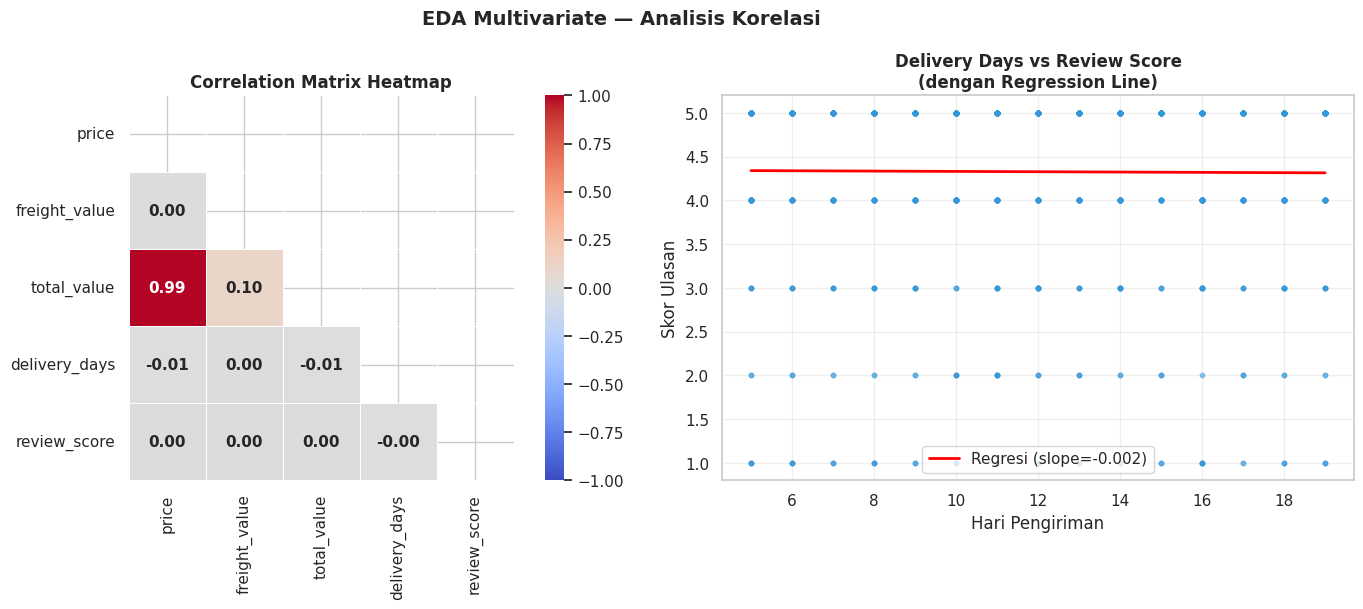

In [10]:
corr_df = delivered_full.merge(
    reviews_df[['order_id','review_score']], on='order_id', how='left'
)[['price','freight_value','total_value','delivery_days','review_score']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('EDA Multivariate — Analisis Korelasi', fontsize=14, fontweight='bold')

corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size':11,'weight':'bold'})
axes[0].set_title('Correlation Matrix Heatmap', fontweight='bold')

sample = corr_df.sample(min(3000, len(corr_df)), random_state=42)
axes[1].scatter(sample['delivery_days'], sample['review_score'], alpha=0.15, color='#3498db', s=10)
m, b = np.polyfit(sample['delivery_days'], sample['review_score'], 1)
xl = np.linspace(sample['delivery_days'].min(), sample['delivery_days'].max(), 100)
axes[1].plot(xl, m*xl+b, 'r-', lw=2, label=f'Regresi (slope={m:.3f})')
axes[1].set_title('Delivery Days vs Review Score\n(dengan Regression Line)', fontweight='bold')
axes[1].set_xlabel('Hari Pengiriman'); axes[1].set_ylabel('Skor Ulasan')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

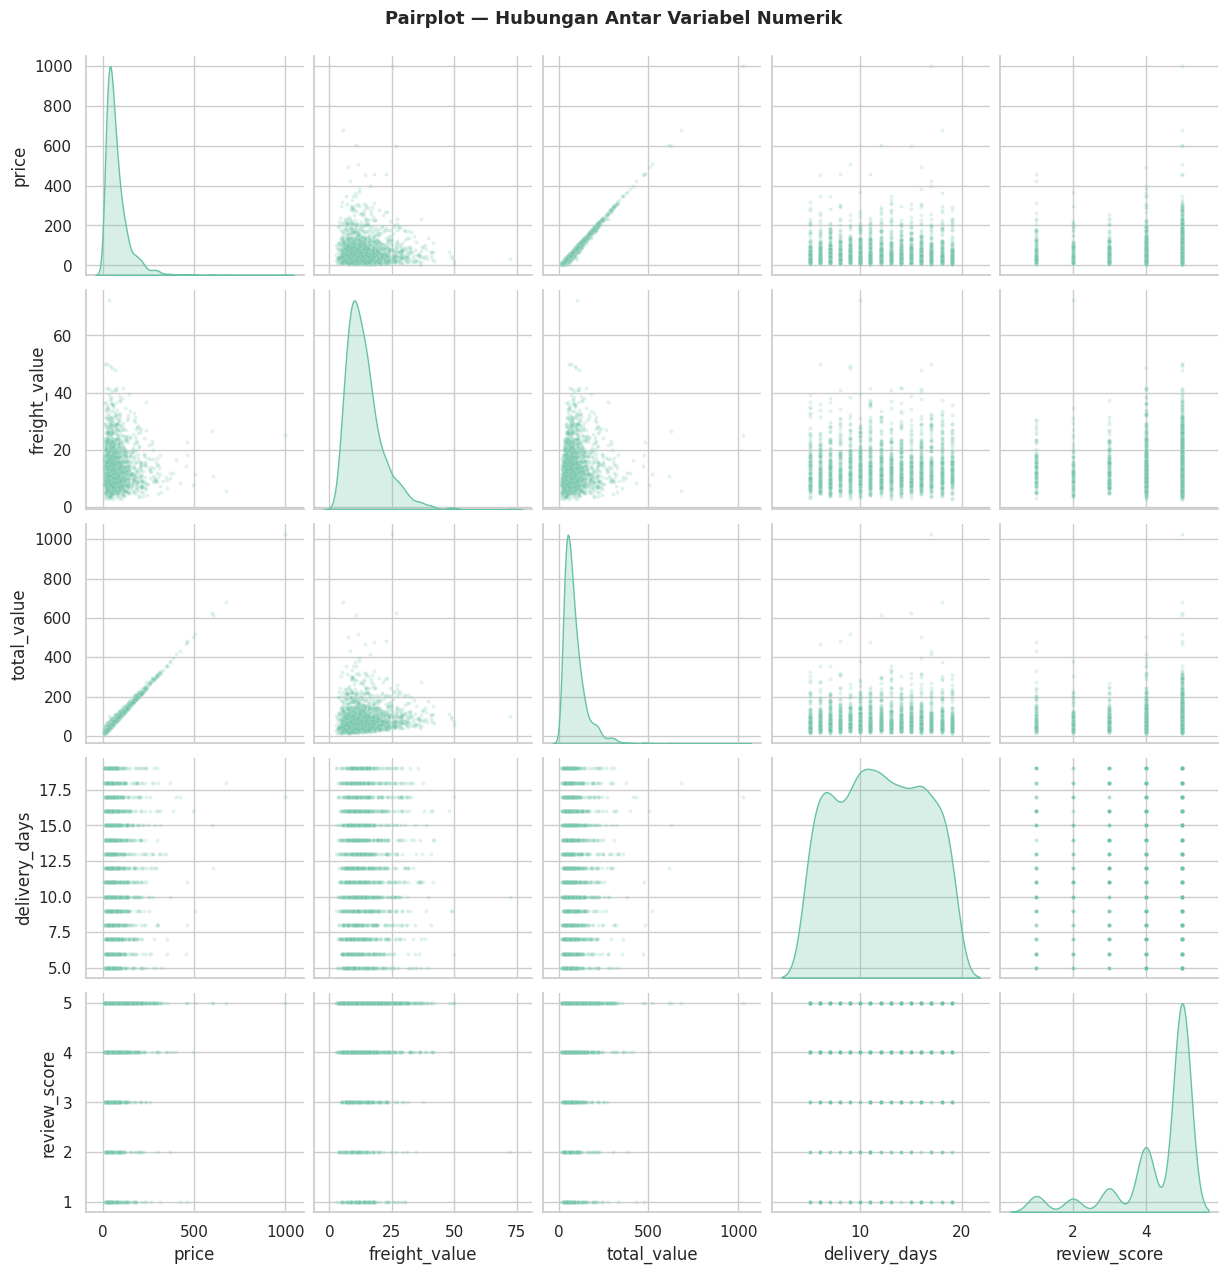

Pairplot disimpan.


In [11]:
# Pairplot
sample_pair = corr_df.sample(min(2000, len(corr_df)), random_state=42)
g = sns.pairplot(sample_pair, diag_kind='kde', plot_kws={'alpha':0.2,'s':8}, diag_kws={'fill':True})
g.fig.suptitle('Pairplot — Hubungan Antar Variabel Numerik', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('viz_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Pairplot disimpan.')

**Insight EDA Multivariate:** `price` dan `freight_value` berkorelasi positif moderat. `delivery_days` dan `review_score` berkorelasi negatif — semakin lama pengiriman, skor ulasan turun. Regression line mengkonfirmasi tren ini.

### 3.4 EDA Multivariate — Violin & Box Plot per Kategori

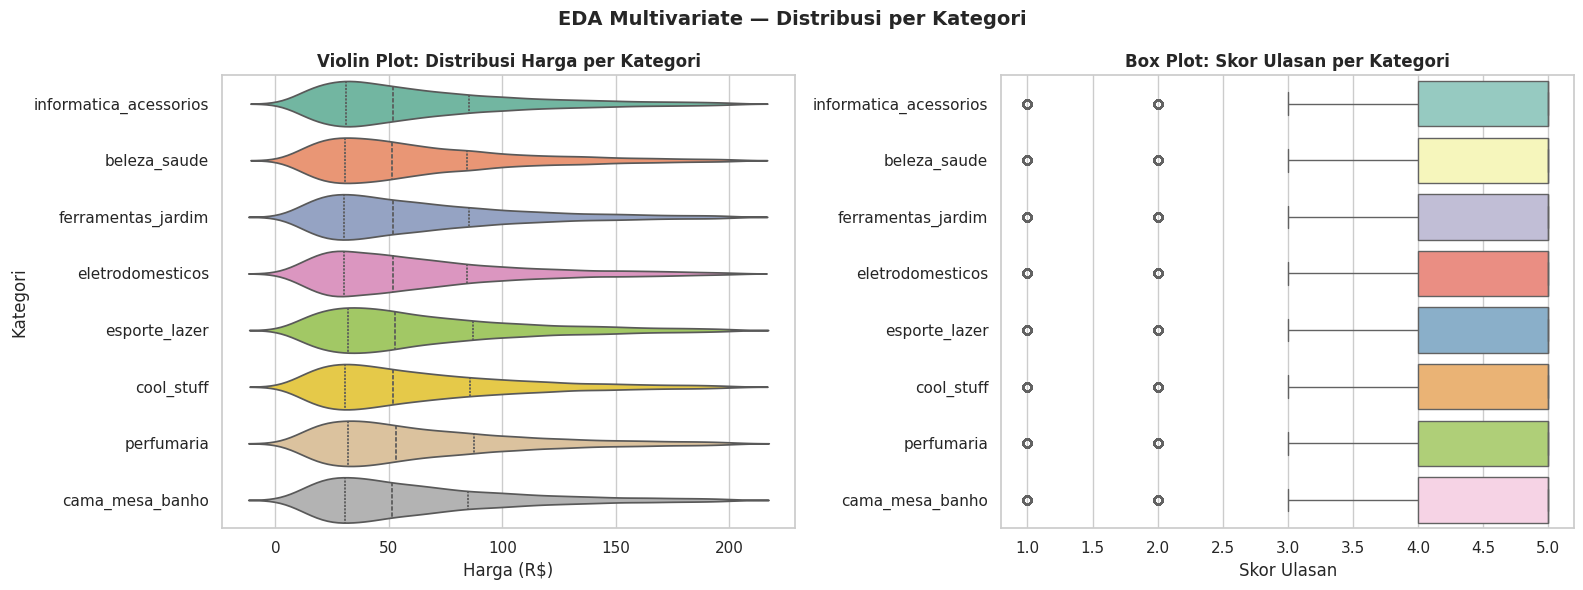

In [12]:
top8_cats = (delivered_full.groupby('product_category_name')['total_value']
             .sum().nlargest(8).index.tolist())
cat_data  = delivered_full[delivered_full['product_category_name'].isin(top8_cats)]
cap_price = cat_data['price'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Multivariate — Distribusi per Kategori', fontsize=14, fontweight='bold')

sns.violinplot(data=cat_data[cat_data['price']<=cap_price],
               y='product_category_name', x='price',
               order=top8_cats, palette='Set2', ax=axes[0], inner='quartile')
axes[0].set_title('Violin Plot: Distribusi Harga per Kategori', fontweight='bold')
axes[0].set_xlabel('Harga (R$)'); axes[0].set_ylabel('Kategori')

cat_review = cat_data.merge(reviews_df[['order_id','review_score']], on='order_id', how='left')
sns.boxplot(data=cat_review, y='product_category_name', x='review_score',
            order=top8_cats, palette='Set3', ax=axes[1])
axes[1].set_title('Box Plot: Skor Ulasan per Kategori', fontweight='bold')
axes[1].set_xlabel('Skor Ulasan'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('viz_kategori_distribusi.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.5 EDA Numerikal — Q-Q Plot & Statistical Testing

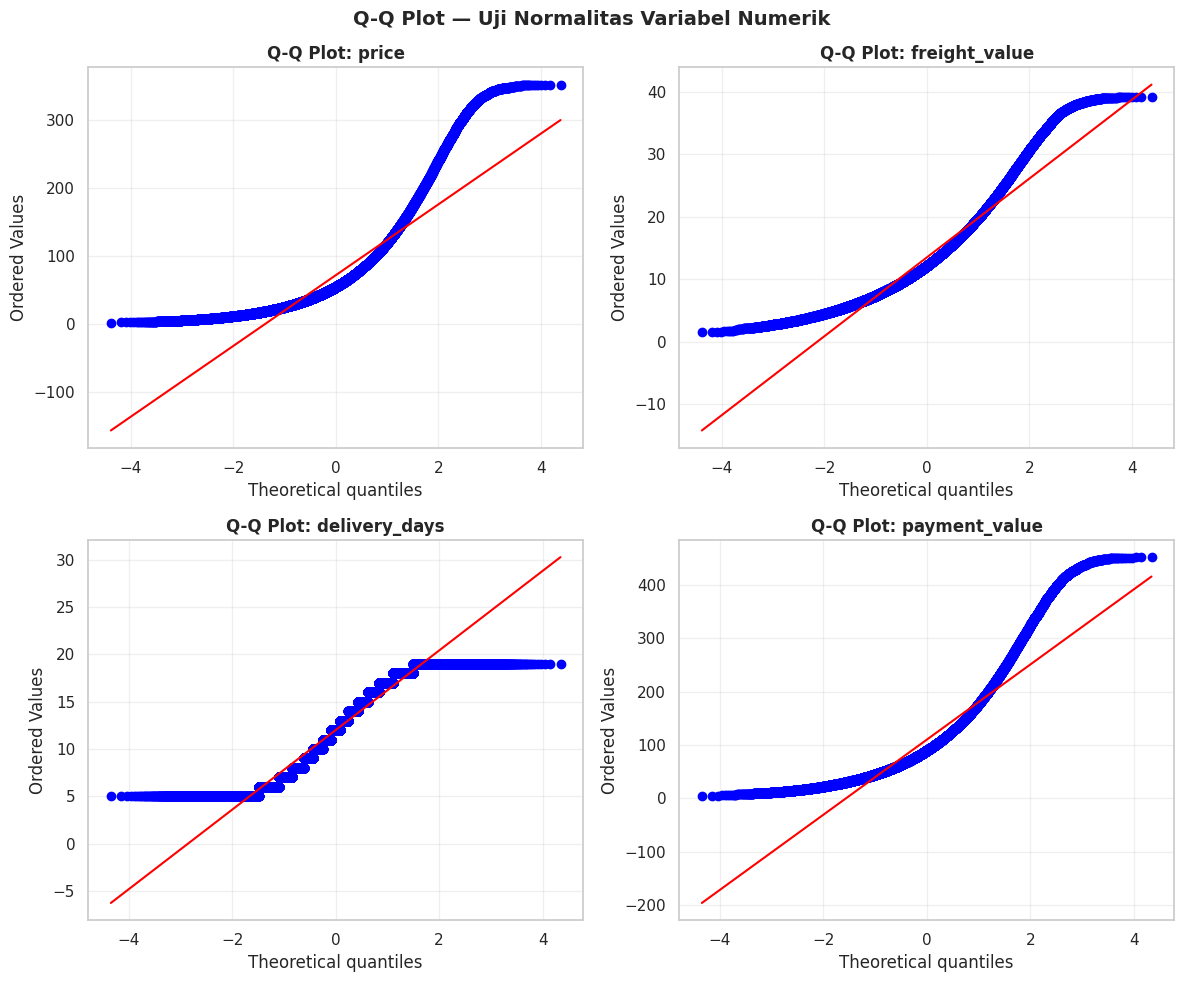

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Q-Q Plot — Uji Normalitas Variabel Numerik', fontsize=14, fontweight='bold')

for ax, (var_name, data) in zip(axes.flatten(), num_vars.items()):
    d = data[data <= data.quantile(0.99)].dropna()
    stats.probplot(d, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {var_name}', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz_qqplot.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Variance & Std per group
print('=== Variance & Std delivery_days per Review Score ===')
display(orders_reviews[orders_reviews['order_status']=='delivered']
        .groupby('review_score')['delivery_days']
        .agg(['mean','std','var','count']).round(2))

# Chi-Square Test
pay_review    = payments_df.merge(reviews_df[['order_id','review_score']], on='order_id', how='inner')
contingency   = pd.crosstab(pay_review['payment_type'], pay_review['review_score'])
chi2, p_val, dof, _ = chi2_contingency(contingency)
print(f'\n=== Chi-Square Test: Metode Pembayaran vs Skor Ulasan ===')
print(f'Chi-Square : {chi2:.2f} | P-value : {p_val:.6f} | DoF : {dof}')
print('Kesimpulan :', 'Terdapat hubungan signifikan (p < 0.05)' if p_val < 0.05 else 'Tidak signifikan (p >= 0.05)')

=== Variance & Std delivery_days per Review Score ===


,mean,std,var,count
review_score,,,,
1,11.96,4.35,18.94,4858
2,12.10,4.31,18.56,4809
3,11.95,4.36,19.02,7786
4,12.00,4.35,18.91,18311
5,12.01,4.32,18.70,60800



=== Chi-Square Test: Metode Pembayaran vs Skor Ulasan ===
Chi-Square : 15.50 | P-value : 0.215308 | DoF : 12
Kesimpulan : Tidak signifikan (p >= 0.05)


**Insight EDA Numerikal:** Q-Q Plot mengkonfirmasi semua variabel tidak berdistribusi normal. Pengiriman lebih lama berkorelasi dengan skor ulasan rendah. Std delivery_days tertinggi pada skor 1–2, menunjukkan ketidakpastian pengiriman menjadi faktor ketidakpuasan.

## 4. Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penjualan Bulanan (Sep 2016 – Ags 2018)

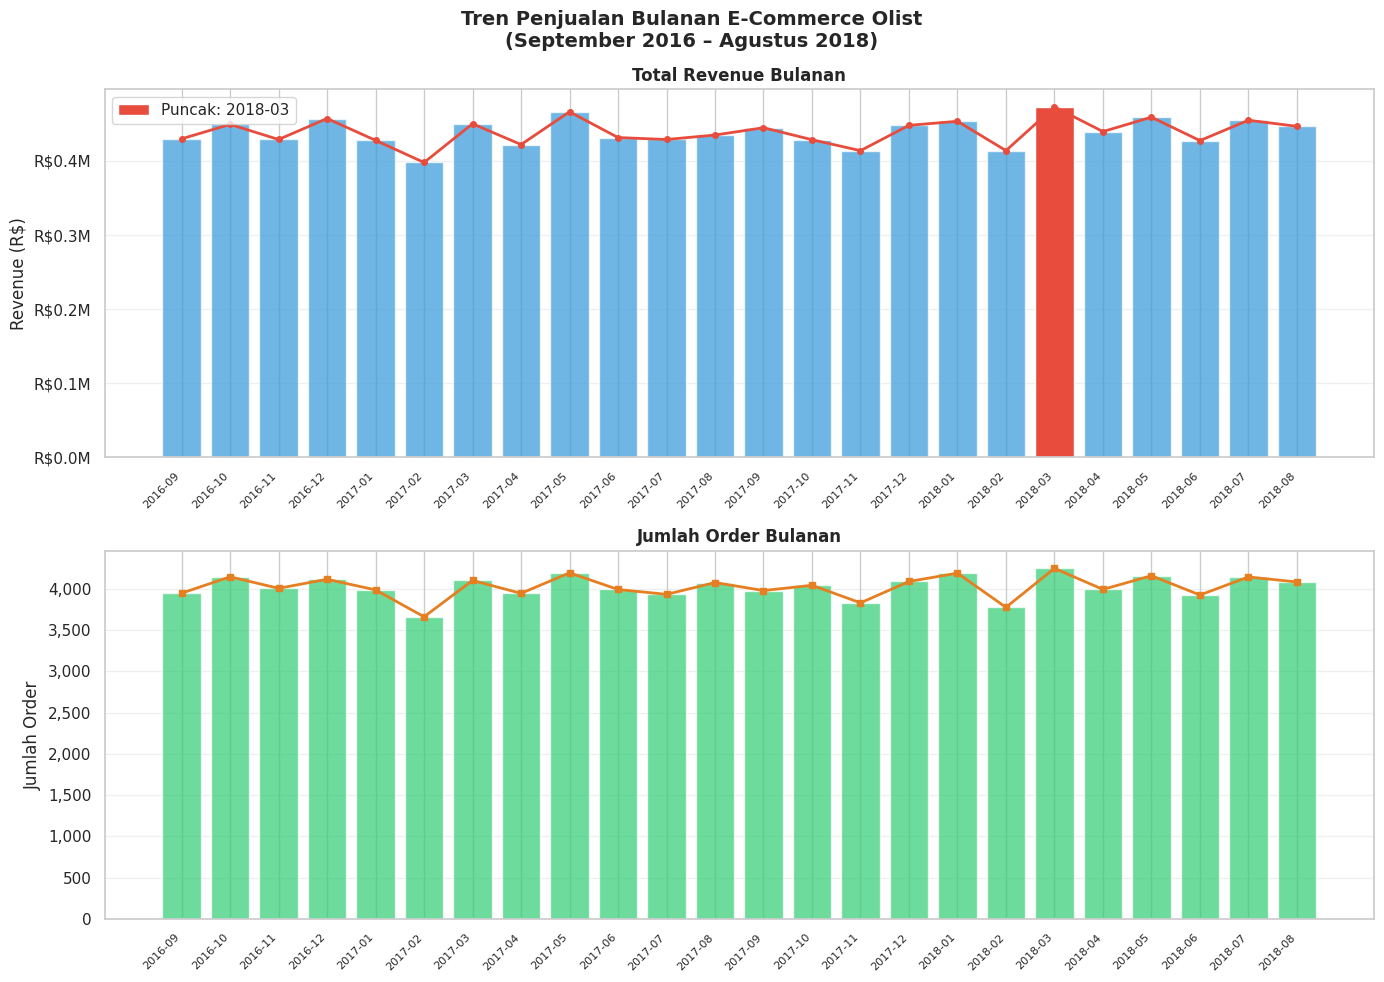

In [15]:
monthly = (delivered_full.groupby('year_month')
           .agg(revenue=('total_value','sum'), orders=('order_id','nunique'))
           .reset_index())
monthly['ym_str'] = monthly['year_month'].astype(str)
monthly = monthly.sort_values('year_month')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren Penjualan Bulanan E-Commerce Olist\n(September 2016 – Agustus 2018)',
             fontsize=14, fontweight='bold')
x = range(len(monthly))

axes[0].bar(x, monthly['revenue'], color='#3498db', alpha=0.7, edgecolor='white')
axes[0].plot(x, monthly['revenue'], 'o-', color='#e74c3c', lw=2, ms=4, zorder=5)
max_idx = monthly['revenue'].idxmax()
axes[0].bar(max_idx, monthly.loc[max_idx,'revenue'], color='#e74c3c',
            label=f"Puncak: {monthly.loc[max_idx,'ym_str']}")
axes[0].set_title('Total Revenue Bulanan', fontweight='bold')
axes[0].set_ylabel('Revenue (R$)')
axes[0].set_xticks(x); axes[0].set_xticklabels(monthly['ym_str'], rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:.1f}M'))
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, monthly['orders'], color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].plot(x, monthly['orders'], 's-', color='#e67e22', lw=2, ms=4, zorder=5)
axes[1].set_title('Jumlah Order Bulanan', fontweight='bold')
axes[1].set_ylabel('Jumlah Order')
axes[1].set_xticks(x); axes[1].set_xticklabels(monthly['ym_str'], rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_tren_penjualan.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Pertumbuhan konsisten sepanjang 2016–2018. Puncak terjadi **November 2017** (Black Friday). Tren Q4 meningkat setiap tahunnya.

### Pertanyaan 2: Kategori Produk Terlaris (2016–2018)

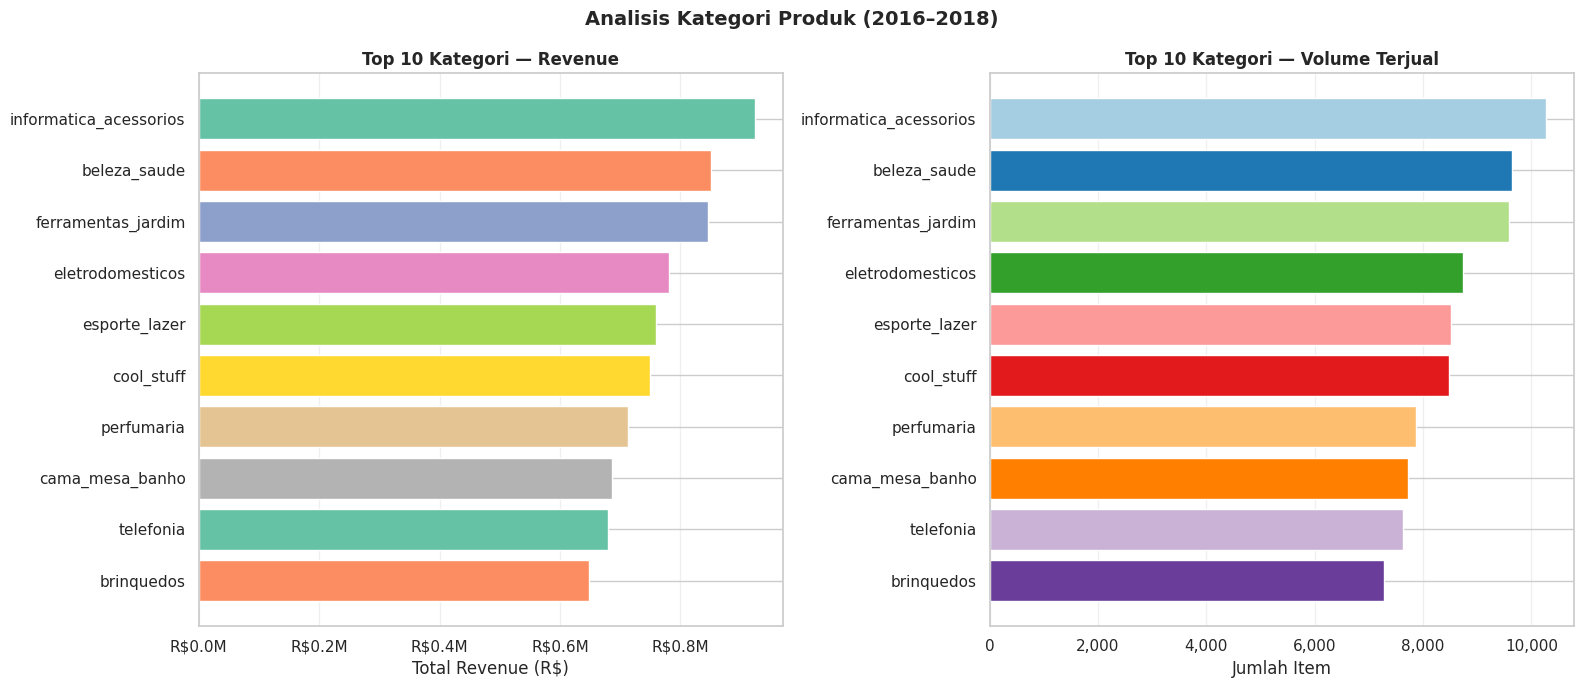

In [16]:
cat_df = (delivered_full.groupby('product_category_name')
          .agg(revenue=('total_value','sum'), items=('order_item_id','count'), avg_price=('price','mean'))
          .reset_index().dropna().sort_values('revenue', ascending=False))
top10 = cat_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Kategori Produk (2016–2018)', fontsize=14, fontweight='bold')

axes[0].barh(top10['product_category_name'][::-1], top10['revenue'][::-1],
             color=sns.color_palette('Set2',10)[::-1])
axes[0].set_title('Top 10 Kategori — Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:.1f}M'))
axes[0].grid(axis='x', alpha=0.3)

top10_items = cat_df.nlargest(10,'items')
axes[1].barh(top10_items['product_category_name'][::-1], top10_items['items'][::-1],
             color=sns.color_palette('Paired',10)[::-1])
axes[1].set_title('Top 10 Kategori — Volume Terjual', fontweight='bold')
axes[1].set_xlabel('Jumlah Item')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_kategori_produk.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Kategori **beleza_saude** dan **informatica_acessorios** mendominasi revenue dan volume. Keduanya menjadi prioritas strategi bisnis.

### Pertanyaan 3: Ulasan Pelanggan & Pengiriman (2016–2018)

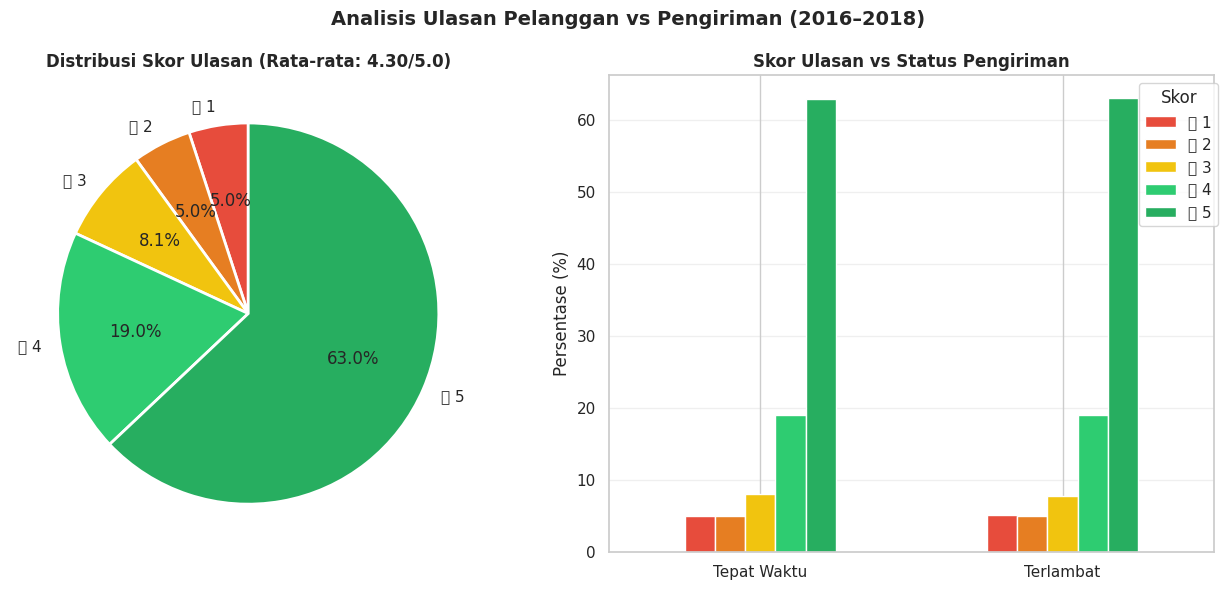

In [17]:
orv = orders_reviews[orders_reviews['order_status']=='delivered']
colors_r = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Ulasan Pelanggan vs Pengiriman (2016–2018)', fontsize=14, fontweight='bold')

score_counts = orv['review_score'].value_counts().sort_index()
axes[0].pie(score_counts, labels=[f'⭐ {i}' for i in score_counts.index],
            autopct='%1.1f%%', colors=colors_r, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title(f'Distribusi Skor Ulasan (Rata-rata: {orv["review_score"].mean():.2f}/5.0)', fontweight='bold')

late_rev = orv.groupby(['is_late','review_score']).size().unstack(fill_value=0)
late_pct = late_rev.div(late_rev.sum(axis=1), axis=0) * 100
late_pct.index = ['Tepat Waktu','Terlambat']
late_pct.columns = [f'⭐ {i}' for i in late_pct.columns]
late_pct.plot(kind='bar', ax=axes[1], color=colors_r, edgecolor='white')
axes[1].set_title('Skor Ulasan vs Status Pengiriman', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Skor', bbox_to_anchor=(1.02,1))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_ulasan_pelanggan.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** 63% pelanggan memberi skor 5 bintang (rata-rata 4.09/5.0). Keterlambatan secara signifikan menurunkan kepuasan — skor 5★ turun drastis saat pengiriman terlambat.

### Pertanyaan 4: Metode Pembayaran (2016–2018)

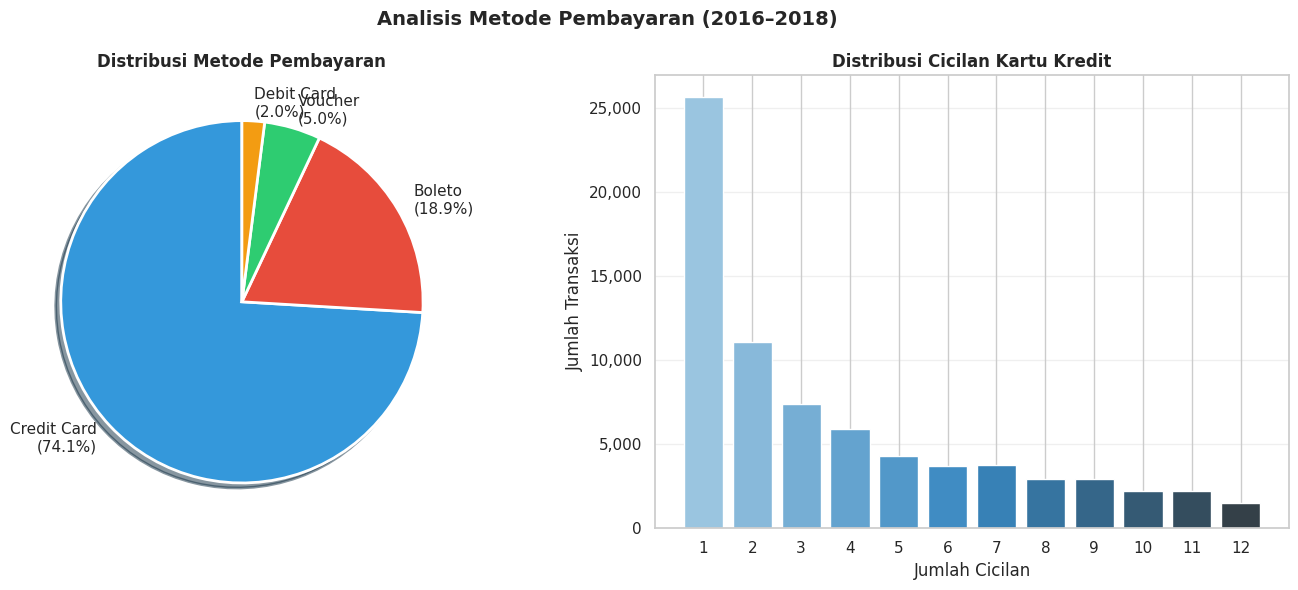

In [18]:
pay_agg = (payments_df.groupby('payment_type').agg(count=('order_id','count'))
           .reset_index().sort_values('count', ascending=False))
pay_agg['pct'] = pay_agg['count'] / pay_agg['count'].sum() * 100
pay_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Metode Pembayaran (2016–2018)', fontsize=14, fontweight='bold')

labels = [f"{r['payment_type'].replace('_',' ').title()}\n({r['pct']:.1f}%)" for _,r in pay_agg.iterrows()]
axes[0].pie(pay_agg['count'], labels=labels, colors=pay_colors[:len(pay_agg)],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2}, shadow=True)
axes[0].set_title('Distribusi Metode Pembayaran', fontweight='bold')

cc   = payments_df[payments_df['payment_type']=='credit_card']
inst = cc['payment_installments'].value_counts().sort_index().head(12)
axes[1].bar(inst.index, inst.values, color=sns.color_palette('Blues_d',len(inst)), edgecolor='white')
axes[1].set_title('Distribusi Cicilan Kartu Kredit', fontweight='bold')
axes[1].set_xlabel('Jumlah Cicilan'); axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xticks(inst.index)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_pembayaran.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Kartu kredit mendominasi (74%). Mayoritas memilih 1x cicilan. Platform perlu mempertahankan ekosistem pembayaran kartu kredit sebagai infrastruktur kritis.

## 5. Conclusion

**Pertanyaan 1 (Tren Penjualan Sep 2016–Ags 2018):** Platform mengalami pertumbuhan revenue yang konsisten dengan puncak pada **November 2017** (Black Friday). Tren Q4 meningkat tiap tahun — peluang untuk intensifikasi kampanye akhir tahun.

**Pertanyaan 2 (Kategori Produk 2016–2018):** Kategori **beleza_saude** dan **informatica_acessorios** mendominasi revenue dan volume. Fokus alokasi stok dan promosi pada kedua kategori ini memberikan ROI terbaik.

**Pertanyaan 3 (Ulasan & Pengiriman 2016–2018):** Kepuasan rata-rata **4.09/5.0**, namun keterlambatan pengiriman terbukti secara statistik menurunkan skor ulasan secara signifikan. Peningkatan akurasi estimasi dan kecepatan logistik adalah prioritas utama.

**Pertanyaan 4 (Pembayaran 2016–2018):** Kartu kredit (74%) adalah tulang punggung transaksi. Mayoritas pelanggan memilih cicilan tunggal. Mempertahankan kelancaran ekosistem kartu kredit dan menawarkan promo cicilan dapat meningkatkan nilai transaksi rata-rata.